# Coding Practice \#5: Due December 5 at midnight in Canvas

All files needed are located in the 'cp5_data_f25.zip' file.

Answer the questions below in a Jupyter notebook. You can modify this notebook by adding cells with your answers.

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer



os.chdir('/Users/jackson/Documents/ECON570')


## Exercise 0: Kaiman, Jackson
Replace 'Last, First' above with your actual name. Enter it as your last name, first name.

## Exercise 1: Regression Problem

1. Read in the file 'bikeshare.csv' and parse dates on the `datetime` column.

In [2]:
df = pd.read_csv('data/bikeshare.csv', parse_dates=['datetime'])

2. From the `datetime` column, create columns for hour of day, month, and an indicator for year 2012. Then, drop the datetime column.

In [3]:
df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month
df['is_2012'] = (df['datetime'].dt.year == 2012).astype(int)

df = df.drop(columns=['datetime'])
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,hour,month,is_2012
0,1,0,0,1,9.84,14.395,81,0.0,16,0,1,0
1,1,0,0,1,9.02,13.635,80,0.0,40,1,1,0
2,1,0,0,1,9.02,13.635,80,0.0,32,2,1,0
3,1,0,0,1,9.84,14.395,75,0.0,13,3,1,0
4,1,0,0,1,9.84,14.395,75,0.0,1,4,1,0


3. The target is `count`. Let's use all other columns as the features. Separate your data into the target y and features X. Then, perform an 80/20 train/test split.

In [4]:
y = df['count']
X = df.drop(columns=['count'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=570
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8708, 11), (2178, 11), (8708,), (2178,))

4. Use the the training data to fit a `LinearRegression` and store predicted values for the testing data. Calculate the root mean squared error on the testing data.

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

142.0010608836693

5. Scatter the actual testing data against the real testing data. Include a 45 degree line. How well does the linear regression fit the data?

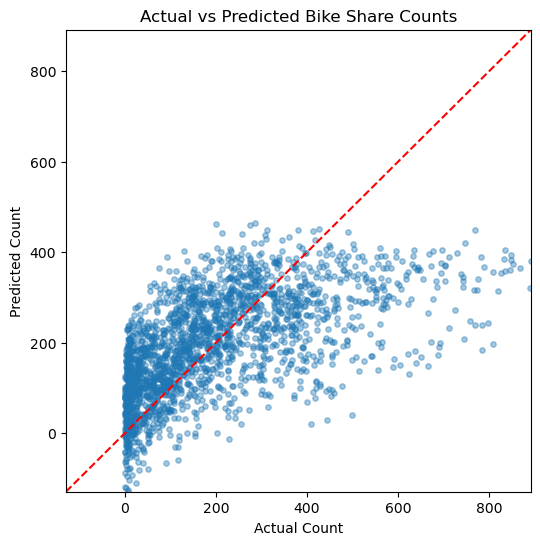

In [6]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_pred, alpha=0.4, s=15)

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--') 

plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("Actual vs Predicted Bike Share Counts")
plt.xlim(lims)
plt.ylim(lims)

plt.show()

6. Let's try to improve the fit using a [random forest](https://en.wikipedia.org/wiki/Random_forest) regressor. Run the following in a code cell. (You may need to change names if you gave your dataframes different names.)

```python
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RMSE for RandomForestRegressor:", root_mean_squared_error(y_test, y_pred_rf))
```

In [7]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RMSE for RandomForestRegressor:", 
      root_mean_squared_error(y_test, y_pred_rf))

RMSE for RandomForestRegressor: 46.63655939768301


7. Scatter the actual testing data against the real testing data. Include a 45 degree line. Compare to the fit of the linear regression model.

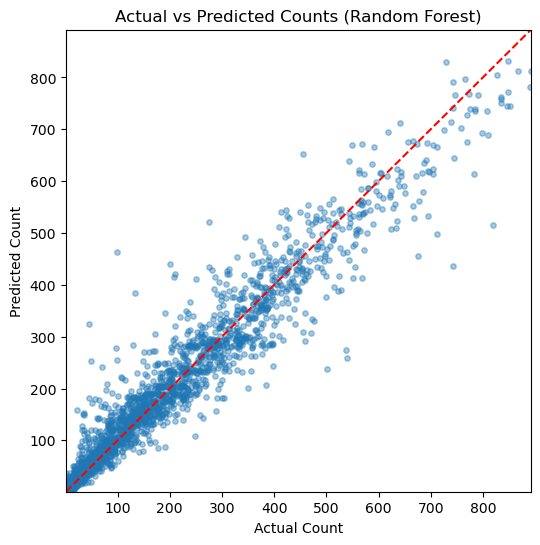

In [8]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.4, s=15)

lims = [min(y_test.min(), y_pred_rf.min()), max(y_test.max(), y_pred_rf.max())]
plt.plot(lims, lims, 'r--')

plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("Actual vs Predicted Counts (Random Forest)")
plt.xlim(lims)
plt.ylim(lims)

plt.show()

## Exercise 2: NLP Classifier

The file 'yelp_reviews.csv' contains 7000 individual yelp reviews along with their star ratings (1-5) and review dates. Let's use some natural language processing tools to build a simple machine learning model that can predict positiveness (as indicated by a high star rating) from review text content.

### Part (a)

1. Read in the file 'yelp_reviews.csv' and parse dates on the `date` column.

In [9]:
df = pd.read_csv('data/yelp_reviews.csv', parse_dates=['date'])
df.head()

,stars,text,date
0,3,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,5,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,3,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,5,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,4,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


2. What is the earliest review year? What is the most recent review year? Use `.value_counts()` to display the number of reviews in each year.

In [10]:
df['year'] = df['date'].dt.year

earliest_year = df['year'].min()
latest_year = df['year'].max()

earliest_year, latest_year

df['year'].value_counts().sort_index()


year
2005      17
2006      12
2007      26
2008      73
2009      97
2010     183
2011     324
2012     472
2013     671
2014     854
2015    1120
2016    1102
2017    1175
2018     874
Name: count, dtype: int64

3. Plot a histogram of star ratings (1-5).

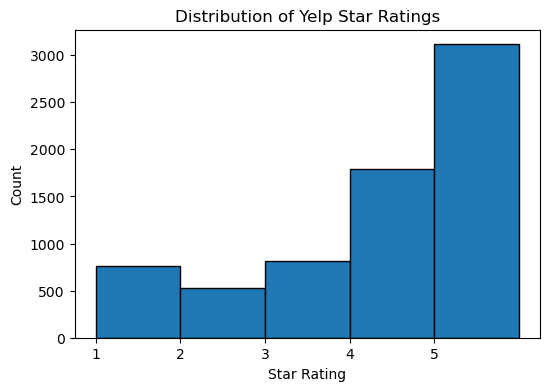

In [11]:
plt.figure(figsize=(6,4))
plt.hist(df['stars'], bins=[1,2,3,4,5,6], edgecolor='black')
plt.xlabel("Star Rating")
plt.ylabel("Count")
plt.title("Distribution of Yelp Star Ratings")
plt.xticks([1,2,3,4,5])
plt.show()

4. Create an indicator variable called 'positive' that is equal to 0 if the review had three or fewer stars and 1 if the review had four or five stars.

In [12]:
df['positive'] = (df['stars'] >= 4).astype(int)

### Part (b)

Let's pre-process the 'text' column using our standard tools.

1. Convert text to lower case
2. Remove non-alphabetic characters
3. Tokenize words
4. Remove stop words
5. Use the PorterStemmer to stem words
6. Convert to a single string with each word separated by spaces.

In [13]:
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

def preprocess(text):
    text = text.lower()
    
    text = re.sub(r'[^a-z]', ' ', text)
    
    tokens = text.split()
    
    tokens = [w for w in tokens if w not in stop_words]
    
    tokens = [ps.stem(w) for w in tokens]
    
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(preprocess)

### Part (c)

1. Use CountVectorizer to vectorize the text data. Limit to 'max_features=100'

In [14]:
cv = CountVectorizer(max_features=100)
X_cv = cv.fit_transform(df['clean_text'])

cv.get_feature_names_out()

array(['also', 'alway', 'amaz', 'area', 'around', 'ask', 'back', 'bar',
       'beer', 'best', 'better', 'burger', 'came', 'chees', 'chicken',
       'come', 'could', 'day', 'definit', 'delici', 'drink', 'eat',
       'enjoy', 'even', 'ever', 'everyth', 'experi', 'first', 'flavor',
       'food', 'fresh', 'fri', 'friend', 'friendli', 'get', 'give', 'go',
       'good', 'got', 'great', 'help', 'hour', 'know', 'like', 'littl',
       'locat', 'look', 'lot', 'love', 'lunch', 'made', 'make', 'meal',
       'menu', 'minut', 'much', 'need', 'never', 'new', 'nice', 'night',
       'one', 'order', 'peopl', 'pizza', 'place', 'pretti', 'price',
       'realli', 'recommend', 'restaur', 'review', 'right', 'room',
       'salad', 'sauc', 'say', 'servic', 'staff', 'star', 'sure', 'tabl',
       'take', 'tast', 'thing', 'think', 'time', 'tri', 'two', 'us',
       'use', 'visit', 'wait', 'walk', 'want', 'way', 'well', 'went',
       'work', 'would'], dtype=object)

2. Using 'positive' as a binary target, split the data in to 80/20 testing/training.

In [15]:
y = df['positive']
X = X_cv

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=570
)

3. Fit a logistic regression to the training data.

In [16]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


4. Calculate the score for the testing data.

In [17]:
test_score = log_reg.score(X_test, y_test)
test_score


0.8028571428571428

5. Calculate the confusion matrix for the testing data and format nicely in pandas. Briefly comment on your results.

In [18]:
y_pred = log_reg.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1']
)

cm_df


,Predicted 0,Predicted 1
Actual 0,211,190
Actual 1,86,913


### Part (d)

Finally, let's consider a commmon alternative to CountVectorizer: [*term frequency-inverse document frequency (tf-idf)*](https://en.wikipedia.org/wiki/Tf–idf). While CountVectorizer takes only simple counts the number of instances of a word in each review, tf-idf adjusts for both the length of the review and the number of times the word appears in all reviews (ie, the corpus).

1. Import the tf-idf Vectorizer and create a vectorizer object using the following.
```python
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
```
Then, `fit_transform()` the pre-processed text data using this vectorizer.

In [19]:
vectorizer = TfidfVectorizer()

X_tfidf = vectorizer.fit_transform(df['clean_text'])

2. Repeat parts 2.-5. from Part c).

In [20]:
X = X_tfidf
y = df['positive']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=570
)

In [21]:
log_reg_tfidf = LogisticRegression(max_iter=1000)
log_reg_tfidf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [22]:
test_score_tfidf = log_reg_tfidf.score(X_test, y_test)
test_score_tfidf


0.8814285714285715

In [23]:
y_pred_tfidf = log_reg_tfidf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_tfidf)

cm_df = pd.DataFrame(
    cm,
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1']
)

cm_df


,Predicted 0,Predicted 1
Actual 0,265,136
Actual 1,30,969
